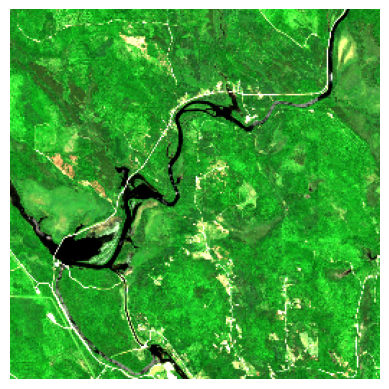

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mosaiks.utils as utl
from mosaiks.fetch import fetch_image_refs, fetch_image_crop

# テスト用 1 座標
#This is around Pittsburg
lat = 44.64695697558939
lon = -71.21401538371171

# 保存先: notebook を script/ から実行しても project root の dataset/ に保存する
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "script" else Path.cwd()
out_dir = PROJECT_ROOT / "dataset" / "test_images"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "test_1coord_landsat_rgb.png"

# MOSAIKS が期待する Lat/Lon + geometry の GeoDataFrame を作る
points_df = pd.DataFrame({"Lat": [lat], "Lon": [lon]})
points_gdf = utl.df_w_latlons_to_gdf(points_df)

# 座標に重なる衛星画像 STAC item を取得
points_with_stac = fetch_image_refs(
    points_gdf=points_gdf,
    satellite_name="sentinel-2-l2a", #Use sentinel 2 for better visualization
    datetime=["2020-01-01", "2020-12-31"],
    image_composite_method="least_cloudy",
    stac_api_name="planetary-compute",
)

stac_items = points_with_stac.loc[0, "stac_item"]

if stac_items is None or len(stac_items) == 0:
    raise RuntimeError("この座標・期間では利用可能な衛星画像が見つかりませんでした。")

# RGB 画像として取得
# Landsat: SR_B4=Red, SR_B3=Green, SR_B2=Blue
img = fetch_image_crop(
    lon=lon,
    lat=lat,
    stac_items=stac_items,
    image_width=256,
    bands=["B04", "B03", "B02"], #R, G, B
    resolution=30,
    dtype="float64",
    image_composite_method="least_cloudy",
    normalise=False,
)

rgb = np.moveaxis(img, 0, -1)

# Landsat Collection 2 Level 2 Surface Reflectance scale/offset
rgb_reflectance = rgb * 0.0000275 - 0.2

lo, hi = np.nanpercentile(rgb_reflectance, [2, 98])
rgb_vis = np.clip((rgb_reflectance - lo) / (hi - lo), 0, 1)

plt.imsave(out_path, rgb_vis)
plt.imshow(rgb_vis)
plt.axis("off")
plt.show()

